Created by Angelo Orletti Del Rey for its masters in psychiatry at Unifesp - SP - Brasil

It was based in our groups previeous works in cotical striatal connectivity in INPD data base of fmri

In [1]:
import numpy as np
import os, sys
import bids
import nibabel as nib
from scipy.stats import pearsonr
from scipy.stats import chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import NegativeBinomial
# from nilearn import plotting as nplot
# from nilearn import image as nimg
# from nilearn.image import resample_to_img
import matplotlib.pyplot as plt
import argparse
import pandas as pd

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
# from scipy.linalg import LinAlgError

# Suppress convergence warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")


In [2]:
def parse():

        options = argparse.ArgumentParser(description="Run 1st level analysis. Created by ...")
        options.add_argument('-p', '--participants', nargs='+',dest="participants", action='store', type=str, required=False,
                            help='id of subject or list of subjects')
        options.set_defaults(participants=None)
        options.add_argument('-w', '--workdir',dest="workdir", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(workdir=os.environ["ROOTDIR"])
        options.add_argument('-b', '--bidsdir',dest="rawdata", action='store', type=str, required=False,
                            help='the work directory for the project')
        options.set_defaults(rawdata=os.path.join(os.environ["ROOTDIR"],"BIDS"))
        options.add_argument('-d', '--derivatives',dest="derivatives", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        options.add_argument('-o', '--outputs',dest="output", action='store', type=str, required=True,
                            help='path to fMRIprep directory')
        #print(options.parse_args())

        return options.parse_args()

os.environ["ROOTDIR"] = r'D://'   # seth path
rootdir = os.environ["ROOTDIR"]
if hasattr(sys, "ps1"):
    options = {}
    workdir = os.environ["ROOTDIR"]
    firstleveldir  = os.path.join(workdir,"BIDS","derivatives","first_level_results")
    demographic = os.path.join(workdir,"metadata")
    confounds = os.path.join(workdir,"metadata")
    output = os.path.join(workdir,'second_level_results')
    participants = []

else :
    options = parse()
    participants = options.participants
    workdir = options.workdir
    rawdata = options.rawdata
    derivat = options.derivatives
    output  = options.outputs

print('firstlevel: ', firstleveldir)
    
bidslayout = bids.BIDSLayout(firstleveldir, validate = False) #With validate = True it doesn't find any subjects

if not participants:
    participants = bidslayout.get_subjects() #take all subjects
    #participants_sub = ["sub-" + item for item in participants]

seednames = ['DCPutamen',
            'DorsalCaudate',
            'DRPutamen',
            'InfVentralCaudate',
            'SupVentralCaudate',
            'VRPutamen'
            ]

tmap_allsubj = [] #initialize array for tmaps

print("Loading tmaps for all participants...")
for p in participants:
    #print(f"Subject: {p}")
    p = p.replace("sub-", "")

    # for ses in bidslayout.get_sessions(subject=p):
    #     #print(f"Session: {ses}")                
    
    ses = '1'

    for r in bidslayout.get_runs(subject=p, session=ses):
        #print(f"Run: {r}")

        tmap_metadata = {
            'task': 'rest',
            'suffix': 'tstat',
            'extension': '.txt',
            'run': str(r),
            'session': str(ses),
            'subject': 'sub-'+p,
            'space': 'MNI152NLin2009cAsym',
            'seed': 'SeedtoROI'
        }

        # Save each tmap as a nifti file
        filepath = os.path.join(firstleveldir,tmap_metadata["subject"],"ses-"+tmap_metadata['session'],"func")
        filename = tmap_metadata["subject"] + "_" + \
                    "ses-"+tmap_metadata['session'] + "_" + \
                    "task-"+tmap_metadata['task'] + "_" + \
                    "run-"+tmap_metadata['run'] + "_" + \
                    "space-"+tmap_metadata['space'] + "_" + \
                    "seed-"+tmap_metadata['seed'] + "_" + \
                    tmap_metadata["suffix"] + \
                    tmap_metadata["extension"]
        tmap_path = os.path.join(filepath, filename)

        #load the tmaps for each subject and then append to the tmap_allsubj array
        tmap = pd.read_csv(tmap_path, delimiter=' ', header=None, skiprows=1) #also skips the first row
        tmap.columns = seednames
        tmap_allsubj.append(tmap)

#load socioeconomic and psichometric data for all subjects
print("Loading socioeconomic and psichometric data for all participants...")
socio_psi=pd.read_csv(os.path.join(demographic,'variaveis_analise_conf_nova-exclusão.tsv'), sep='\t')
#substitute in age colunm , to . for decimals if necessary and convert to float
# socio_psi['age'] = socio_psi['age'].str.replace(',', '.').astype(float)

# organinzing the tmaps. Joining the columns of the tmaps for all subjects. So for each subject
# we have to join the first collunm of the first tmap with the first column of the second tmap and so on
# and then join the second column of the first tmap with the second column of the second tmap and so on
# and so on
print("Organizing tmaps...")
tmap_allsubj = pd.concat(tmap_allsubj, axis=1)
tmap_allsubj_organized = {}

for seed in seednames:
    #drop columns with names different from seednames[i]
    tmap_allsubj_organized[seed] = tmap_allsubj.drop(columns=[col for col in tmap_allsubj.columns if col != seed])

# What do we have now: tmap_allsubj_organized is a dictionary with keys being the seednames and values being
# dataframes with the tmaps for all subjects for that seed. This have dimensions of n_ROIs x n_subjects
# Now we have to transpose it to get the data in the format n_subjects x n_ROIs and then join with the
# socioeconomic and psichometric data
# Also, we have to add the sub_id column to the conectivity data to be able to join with the socioeconomic
# and psichometric data
subs = {'sub_id': []}
for p in participants:
    ses = '1'
    if bidslayout.get_runs(subject=p, session=ses) != []:
        subs['sub_id'].append('sub-'+p)

subs = pd.DataFrame(subs)

# create the collunms names for the data frame of rois
roi_names = [f'roi_{i}' for i in range(101)]

for seed in seednames:
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].transpose()
    tmap_allsubj_organized[seed].columns = roi_names
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].reset_index().join(subs, how='inner')
    tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].drop(columns=['index'])

# Now we have to join the tmaps with the socioeconomic and psichometric data
print("Joining tmaps with socioeconomic and psichometric data...")

for seed in seednames:
    tmap_allsubj_organized[seed] = pd.merge(tmap_allsubj_organized[seed], socio_psi, on='sub_id', how='inner')
    # tmap_allsubj_organized[seed] = tmap_allsubj_organized[seed].drop(columns=['Unnamed: 0'])


firstlevel:  D://BIDS\derivatives\first_level_results
Loading tmaps for all participants...
Loading socioeconomic and psichometric data for all participants...
Organizing tmaps...
Joining tmaps with socioeconomic and psichometric data...


In [ ]:
# now we run the regression analysis for each seed. The dependent variable is the connectivity and the independent
# variables are the CAPE scores. The socioeconomic variables are used as confund variables
print("Running regression analysis (salience and defualt mode network)...")

shaeffer_network = pd.read_csv(os.path.join(demographic, 
    'tpl-MNI152NLin2009cAsym_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.tsv'), delimiter='\t')

# running the regression analysis for each roi in the salience network
results_networks = {} #, results_default = {}, {}
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    results_networks[cape] = {}
    for seed in seednames:
        results_networks[cape][seed] = {}
        #salience analisys
        for roi in shaeffer_network['index']:

            #building my strign for the fomrula
            formula = f'{cape} ~ roi_{roi} + age + C(gender) + abepscore + C(colection_site) + fd_mean_value'
            
            #running the regression analysis
            model = smf.glm(formula, data=tmap_allsubj_organized[seed],
                                    family=NegativeBinomial())
            # model_salience = smf.ols(formula_salience, data=tmap_allsubj_organized[seed])
            fit = model.fit()

            # Extract desired values
            results_networks[cape][seed][roi] = {
                'coef': fit.params[f'roi_{roi}'],
                'intercept': fit.params['Intercept'],
                't_value': fit.tvalues[f'roi_{roi}'],
                'p_value': fit.pvalues[f'roi_{roi}'],
                'AIC': fit.aic,
                'BIC': fit.bic,
                'deviance': fit.deviance,
                'degrees_of_freedom': fit._iweights.sum() - len(fit.params),
                'residuals': fit.resid_response,
                'mcFadden_R_squared': 1 - fit.deviance / fit.null_deviance,
                'log_likelihood': fit.llf
            }

Running regression analysis (salience and defualt mode network)...


c:\Users\angel\Documents\masters-uploaded-github\INPD-neuroimage-cape\.venv-CAPE-neuroimag\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1809: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  FutureWarning
c:\Users\angel\Documents\masters-uploaded-github\INPD-neuroimage-cape\.venv-CAPE-neuroimag\lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1809: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of

In [32]:
# correcting the p-values in two types: 
# first corret to all p-values in the comparison (corr_p_val_general).
# second: correct all p-values within each network (corr_p_val_intranetwork)
from statsmodels.stats.multitest import multipletests
for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    for seed in seednames:
        print(f'General FDR - {seed} - {cape}')
        p_values = []

        for roi in results_networks[cape][seed].keys():
            # Extract the p-values for the current seed and roi
            p_values.append(results_networks[cape][seed][roi]['p_value'])

        #correct the p-values using the Benjamini-Hochberg method
        corrected_p_values = multipletests(p_values, method='fdr_bh')[1]

        # Update the results with the corrected p-values
        for index, roi in enumerate(results_networks[cape][seed].keys()):
            results_networks[cape][seed][roi]['corr_p_value_general'] = corrected_p_values[index]

            if results_networks[cape][seed][roi]['corr_p_value_general'] <= 0.05:
                print(f"{cape} roi-{roi} -> corr_p_val_general {results_networks[cape][seed][roi]['corr_p_value_general']}")

        print(f'Intranetwork - {seed} - {cape}')
        # for this we have to do it mannually for each network
        
        # salience_index = shaeffer_network[shaeffer_network['name'].str.contains('SalVentAttn')]
        for network in ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']:
            p_values_net = []

            for roi in shaeffer_network[shaeffer_network['name'].str.contains(network)]['index']:
                # Extract the p-values for the current seed and roi
                p_values_net.append(results_networks[cape][seed][roi]['p_value'])

            #correct the p-values using the Benjamini-Hochberg method
            corrected_p_values_net = multipletests(p_values_net, method='fdr_bh')[1]

            # Update the results with the corrected p-values
            # Iterate only over ROIs in the current network, not all ROIs
            for index, roi in enumerate(shaeffer_network[shaeffer_network['name'].str.contains(network)]['index']):
                results_networks[cape][seed][roi]['corr_p_value_intranetwork'] = corrected_p_values_net[index]

                # Print significant results for intranetwork correction
                if results_networks[cape][seed][roi]['corr_p_value_intranetwork'] <= 0.05:
                    print(f"{cape} roi-{roi} -> corr_p_val_network {results_networks[cape][seed][roi]['corr_p_value_intranetwork']}")

General FDR - DCPutamen - cape_tot
Intranetwork - DCPutamen - cape_tot
General FDR - DorsalCaudate - cape_tot
Intranetwork - DorsalCaudate - cape_tot
General FDR - DRPutamen - cape_tot
Intranetwork - DRPutamen - cape_tot
General FDR - InfVentralCaudate - cape_tot
Intranetwork - InfVentralCaudate - cape_tot
General FDR - SupVentralCaudate - cape_tot
Intranetwork - SupVentralCaudate - cape_tot
General FDR - VRPutamen - cape_tot
Intranetwork - VRPutamen - cape_tot
General FDR - DCPutamen - cape_PA_score
Intranetwork - DCPutamen - cape_PA_score
General FDR - DorsalCaudate - cape_PA_score
Intranetwork - DorsalCaudate - cape_PA_score
cape_PA_score roi-79 -> corr_p_val_network 0.04310936232038761
General FDR - DRPutamen - cape_PA_score
cape_PA_score roi-13 -> corr_p_val_general 0.01188336098828434
cape_PA_score roi-31 -> corr_p_val_general 0.033427204269826705
cape_PA_score roi-36 -> corr_p_val_general 0.027876336417304397
cape_PA_score roi-44 -> corr_p_val_general 0.01188336098828434
cape_PA

In [ ]:
# Merge all regression parameters into a single dataframe grouped by CAPE and seed
all_results = []

for cape in ['cape_tot', 'cape_PA_score', 'cape_PI_score', 'cape_BE_score']:
    # Process salience network results
    for seed in seednames:
        for network in ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']:
            for roi in shaeffer_network[shaeffer_network['name'].str.contains(network)]['index']:
                # Get the result values as a dictionary
                result_dict = results_networks[cape][seed][roi].to_dict('records')[0] if isinstance(results_networks[cape][seed][roi], pd.DataFrame) else results_networks[cape][seed][roi]
                # Add metadata columns
                result_dict['CAPE'] = cape
                result_dict['seed'] = seed
                result_dict['network'] = network
                result_dict['ROI'] = roi
                all_results.append(result_dict)
    

# Create dataframe from list of dictionaries
merged_df = pd.DataFrame(all_results)

# Reorder columns for better readability
column_order = ['CAPE', 'seed', 'network', 'ROI', 'coef', 'intercept', 't_value', 'p_value', 
                'corr_p_value_general', 'corr_p_value_intranetwork', 'AIC', 'BIC', 'deviance',
                'degrees_of_freedom', 'residuals', 'mcFadden_R_squared', 'log_likelihood']
merged_df = merged_df[column_order]

# Save to CSV
merged_df.to_csv(os.path.join(output, 'results_2ndlvl.csv'), index=False)

print(f"Merged dataframe saved to: {os.path.join(output, 'results_2ndlvl.csv')}")
print(f"Shape: {merged_df.shape}")
print(f"\nFirst few rows:")
print(merged_df.head(10))

Merged dataframe saved to: D://second_level_results\results_2ndlvl.csv
Shape: (2400, 18)

First few rows:
       CAPE       seed network  ROI          coef  intercept   t_value  \
0  cape_tot  DCPutamen     Vis    1  6.093508e-02   1.253323  2.133077   
1  cape_tot  DCPutamen     Vis    2  1.827361e-02   1.374100  0.756179   
2  cape_tot  DCPutamen     Vis    3  1.781277e-02   1.371318  0.723772   
3  cape_tot  DCPutamen     Vis    4  1.752309e-02   1.340006  0.920420   
4  cape_tot  DCPutamen     Vis    5  2.337136e-15   1.451242  0.544512   
5  cape_tot  DCPutamen     Vis    6  3.586030e-02   1.316039  1.752577   
6  cape_tot  DCPutamen     Vis    7  4.511984e-03   1.445205  0.221822   
7  cape_tot  DCPutamen     Vis    8  2.688907e-02   1.383376  1.149929   
8  cape_tot  DCPutamen     Vis    9  2.096089e-02   1.416730  1.006566   
9  cape_tot  DCPutamen     Vis   51  6.176845e-02   1.364911  2.379542   

    p_value  corr_p_value_general  corr_p_value_intranetwork          AIC  \
0 

Text(0.5, 1.0, 'Distribution of Residuals')

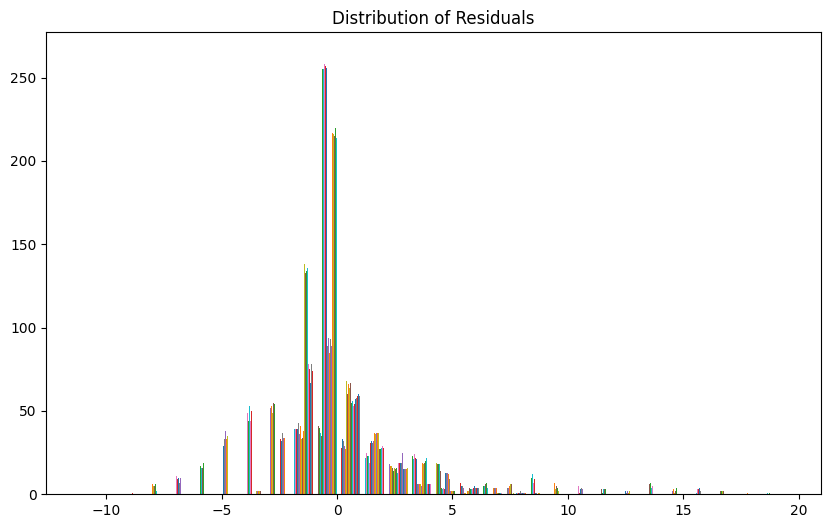

In [ ]:
# plot a summary of the residuals distribution
plt.figure(figsize=(10, 6))
plt.hist(merged_df['residuals'])
plt.title('Distribution of Residuals')

Text(0, 0.5, "McFadden's R-squared")

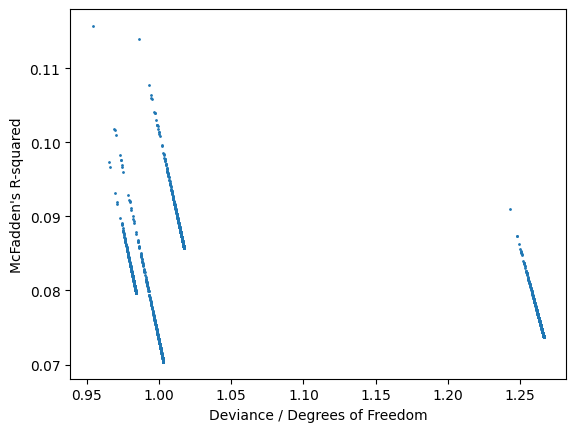

In [20]:
plt.plot(merged_df['deviance']/merged_df['degrees_of_freedom'], merged_df['mcFadden_R_squared'], 'o',
         markersize = 1)
plt.xlabel('Deviance / Degrees of Freedom')
plt.ylabel("McFadden's R-squared")

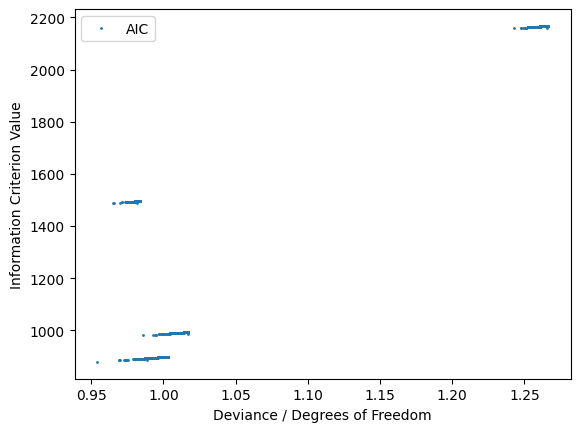

In [23]:
# visualize the AIC and BIC values for each model
plt.plot(merged_df['deviance']/merged_df['degrees_of_freedom'], merged_df['AIC'], 'o',
         markersize = 1, label='AIC')
# plt.plot(merged_df['deviance']/merged_df['degrees_of_freedom'], merged_df['BIC'], 'o',
#          markersize = 1, label='BIC')
plt.xlabel('Deviance / Degrees of Freedom')
plt.ylabel('Information Criterion Value')
plt.legend()